
# AI Business Analyst Assistant
**Dataset:** Olist Brazilian E-Commerce — 8 tables covering orders, customers, products, sellers,
payments, and reviews.

### Day 1: Database Setup + Schema Exploration
## 1. Load CSVs into SQLite

In [ ]:
import pandas as pd
import sqlite3
import os

DATA_DIR = '/content/sample_data/'
DB_PATH = '/content/sample_data/olist.db'

# Remove any existing DB so this notebook can be re-run cleanly
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

conn = sqlite3.connect(DB_PATH)

# Map: CSV filename -> table name
files_to_tables = {
    'olist_orders_dataset.csv': 'orders',
    'olist_order_items_dataset.csv': 'order_items',
    'olist_order_payments_dataset.csv': 'order_payments',
    'olist_order_reviews_dataset.csv': 'order_reviews',
    'olist_products_dataset.csv': 'products',
    'olist_sellers_dataset.csv': 'sellers',
    'olist_customers_dataset.csv': 'customers',
    'product_category_name_translation.csv': 'category_translation',
}

for filename, table_name in files_to_tables.items():
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path)
    df.to_sql(table_name, conn, if_exists='replace', index=False)
    print(f"Loaded {table_name}: {df.shape[0]} rows, {df.shape[1]} columns")

conn.commit()
print("\nDatabase created at:", DB_PATH)

Loaded orders: 99441 rows, 8 columns
Loaded order_items: 112650 rows, 7 columns
Loaded order_payments: 103886 rows, 5 columns
Loaded order_reviews: 99224 rows, 7 columns
Loaded products: 32951 rows, 9 columns
Loaded sellers: 3095 rows, 4 columns
Loaded customers: 99441 rows, 5 columns
Loaded category_translation: 71 rows, 2 columns

Database created at: /content/sample_data/olist.db


## 2. Confirm Tables Loaded Correctly

In [ ]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                   name
0                orders
1           order_items
2        order_payments
3         order_reviews
4              products
5               sellers
6             customers
7  category_translation


## 3. Understand the Schema

Here's how the 8 tables connect (this isn't enforced by SQLite automatically, but it's the logical
relationship our SQL queries — and later, the LLM's generated SQL — need to respect):

```
customers (customer_id) ─────┐
                              │
orders (customer_id, order_id)
   │
   ├── order_items (order_id, product_id, seller_id) ── products (product_id)
   │                                                  └── sellers (seller_id)
   ├── order_payments (order_id)
   └── order_reviews (order_id)

products (product_category_name) ── category_translation (product_category_name)
```

**Key join paths to remember:**
- Revenue questions → `order_items` (has `price`) joined to `orders` (has purchase date)
- "Which customer" questions → `orders.customer_id` → `customers.customer_id`
- "Which category" questions → `order_items.product_id` → `products.product_id` → `category_translation`
- "Which seller" questions → `order_items.seller_id` → `sellers.seller_id`


In [ ]:
# Preview each table's columns and a sample row
for table_name in files_to_tables.values():
    print(f"--- {table_name} ---")
    sample = pd.read_sql(f"SELECT * FROM {table_name} LIMIT 2", conn)
    print(list(sample.columns))
    print()

--- orders ---
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

--- order_items ---
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

--- order_payments ---
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

--- order_reviews ---
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

--- products ---
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

--- sellers ---
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

--- customers ---
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix

## 4. Manual Business Queries (Ground Truth)

We write these ourselves and verify they make sense — these become our answer key for testing the
LLM's generated SQL tomorrow.


### Q1: What's the total revenue, and over what date range?

In [ ]:
query = '''
SELECT
    ROUND(SUM(oi.price), 2) AS total_revenue,
    MIN(o.order_purchase_timestamp) AS earliest_order,
    MAX(o.order_purchase_timestamp) AS latest_order
FROM order_items oi
JOIN orders o ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
'''
result = pd.read_sql(query, conn)
result

,total_revenue,earliest_order,latest_order
0,13221498.11,2016-09-15 12:16:38,2018-08-29 15:00:37


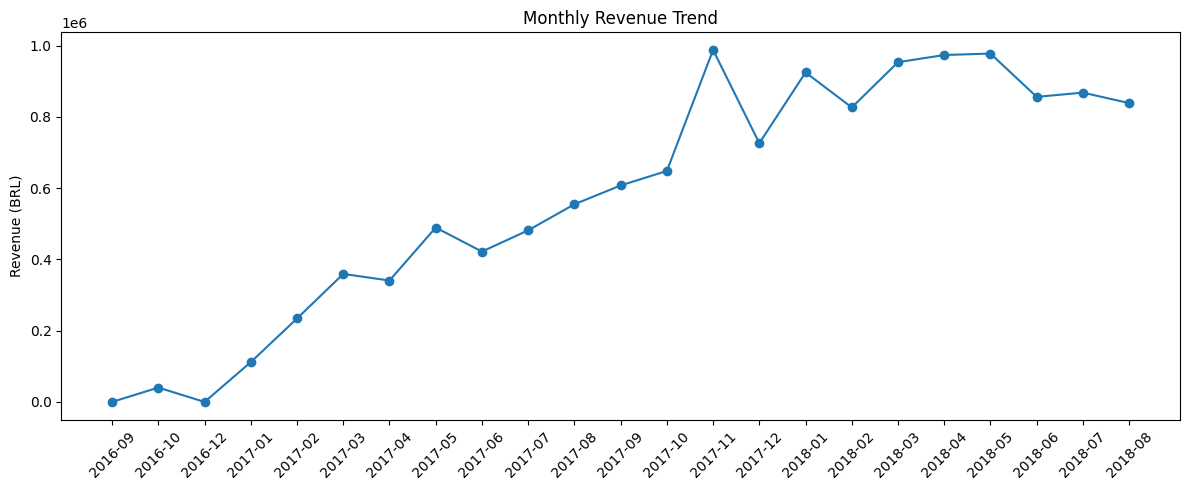

In [ ]:
import matplotlib.pyplot as plt

# Calculate monthly revenue
monthly_revenue_query = '''
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    ROUND(SUM(oi.price), 2) AS revenue
FROM order_items oi
JOIN orders o ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY month
ORDER BY month
'''
monthly = pd.read_sql(monthly_revenue_query, conn)

plt.figure(figsize=(12,5))
plt.plot(monthly['month'], monthly['revenue'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (BRL)')
plt.tight_layout()
plt.show()

**Look at this chart carefully and note any sharp drops or the trailing incomplete month** —
Olist's data collection ends abruptly, so the last month or two is often a partial/incomplete period,
not a real business decline. This is another thing to flag for the LLM's prompt tomorrow: it shouldn't
interpret a partial final month as a genuine "revenue drop."

### Q3: Top 5 product categories by revenue (English names)

In [ ]:
query = '''
SELECT
    ct.product_category_name_english AS category,
    ROUND(SUM(oi.price), 2) AS revenue,
    COUNT(*) AS items_sold
FROM order_items oi
JOIN orders o ON oi.order_id = o.order_id
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY revenue DESC
LIMIT 5
'''
pd.read_sql(query, conn)

,category,revenue,items_sold
0,health_beauty,1233131.72,9465
1,watches_gifts,1166176.98,5859
2,bed_bath_table,1023434.76,10953
3,sports_leisure,954852.55,8431
4,computers_accessories,888724.61,7644


### Q4: Average order value


In [ ]:
query = '''
SELECT ROUND(AVG(order_total), 2) AS avg_order_value
FROM (
    SELECT oi.order_id, SUM(oi.price) AS order_total
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY oi.order_id
)
'''
pd.read_sql(query, conn)

,avg_order_value
0,137.04


### Q5: Top 5 sellers by revenue

In [ ]:
query = '''
SELECT
    s.seller_id,
    s.seller_state,
    ROUND(SUM(oi.price), 2) AS revenue,
    COUNT(*) AS items_sold
FROM order_items oi
JOIN orders o ON oi.order_id = o.order_id
JOIN sellers s ON oi.seller_id = s.seller_id
WHERE o.order_status = 'delivered'
GROUP BY s.seller_id
ORDER BY revenue DESC
LIMIT 5
'''
pd.read_sql(query, conn)

,seller_id,seller_state,revenue,items_sold
0,4869f7a5dfa277a7dca6462dcf3b52b2,SP,226987.93,1148
1,53243585a1d6dc2643021fd1853d8905,BA,217940.44,400
2,4a3ca9315b744ce9f8e9374361493884,SP,196882.12,1949
3,fa1c13f2614d7b5c4749cbc52fecda94,SP,190917.14,579
4,7c67e1448b00f6e969d365cea6b010ab,SP,186570.05,1355


### Q6: Average review score, and does it vary by category?

In [ ]:
query = '''
SELECT
    ct.product_category_name_english AS category,
    ROUND(AVG(r.review_score), 2) AS avg_review_score,
    COUNT(*) AS num_reviews
FROM order_reviews r
JOIN orders o ON r.order_id = o.order_id
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
GROUP BY category
HAVING num_reviews > 100
ORDER BY avg_review_score ASC
LIMIT 5
'''
pd.read_sql(query, conn)

,category,avg_review_score,num_reviews
0,office_furniture,3.49,1687
1,fashion_male_clothing,3.64,131
2,fixed_telephony,3.68,262
3,audio,3.83,361
4,home_confort,3.83,435


**Note:** we added `HAVING num_reviews > 100` — without this, categories with just 1-2 reviews could
show a misleadingly extreme average (e.g., a single 1-star review = 1.0 average). This is the kind of
statistical judgment call the LLM won't make automatically unless the prompt guides it.


### Day 2: Text-to-SQL Core
## 1. Connect to the Database


In [ ]:
import sqlite3
import pandas as pd
import os

conn = sqlite3.connect('/content/sample_data/olist.db')

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                   name
0                orders
1           order_items
2        order_payments
3         order_reviews
4              products
5               sellers
6             customers
7  category_translation


## 2. Extract the Schema Automatically

Rather than hardcoding the schema as text (which goes stale if the database changes), we pull it
directly from SQLite. This schema string is what gets sent to the LLM so it knows exactly what
tables and columns exist — the LLM can't write correct SQL for tables it doesn't know about.

In [ ]:
def get_schema_text(conn):
    tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist()
    schema_parts = []
    for table in tables:
        cols = pd.read_sql(f"PRAGMA table_info({table})", conn)
        col_list = ", ".join(f"{row['name']} ({row['type']})" for _, row in cols.iterrows())
        schema_parts.append(f"Table: {table}\nColumns: {col_list}")
    return "\n\n".join(schema_parts)

schema_text = get_schema_text(conn)
print(schema_text)

Table: orders
Columns: order_id (TEXT), customer_id (TEXT), order_status (TEXT), order_purchase_timestamp (TEXT), order_approved_at (TEXT), order_delivered_carrier_date (TEXT), order_delivered_customer_date (TEXT), order_estimated_delivery_date (TEXT)

Table: order_items
Columns: order_id (TEXT), order_item_id (INTEGER), product_id (TEXT), seller_id (TEXT), shipping_limit_date (TEXT), price (REAL), freight_value (REAL)

Table: order_payments
Columns: order_id (TEXT), payment_sequential (INTEGER), payment_type (TEXT), payment_installments (INTEGER), payment_value (REAL)

Table: order_reviews
Columns: review_id (TEXT), order_id (TEXT), review_score (INTEGER), review_comment_title (TEXT), review_comment_message (TEXT), review_creation_date (TEXT), review_answer_timestamp (TEXT)

Table: products
Columns: product_id (TEXT), product_category_name (TEXT), product_name_lenght (REAL), product_description_lenght (REAL), product_photos_qty (REAL), product_weight_g (REAL), product_length_cm (REAL)

## 3. Design the Text-to-SQL Prompt

A few deliberate choices, worth being able to explain in an interview:

- **We give the LLM the full schema every time** — it has no memory between calls, so context must
  be self-contained in each prompt.
- **We tell it the join relationships explicitly** — column names alone (`order_id`, `product_id`)
  don't tell the LLM which tables to join; SQLite has no foreign key metadata loaded, so we state it
  in plain English.
- **We bake in the business logic we discovered on Day 1** — filtering to `delivered` orders, and
  being cautious about the incomplete first/last months. Without this, the LLM would technically
  answer correctly but businesswise misleadingly (e.g., panicking about a "revenue crash" that's
  actually just a data collection artifact).
- **We ask for SQL only, no explanation text** — makes the response easy to parse and execute directly.

In [ ]:
SCHEMA_CONTEXT = f'''
{schema_text}

Key relationships:
- orders.customer_id = customers.customer_id
- order_items.order_id = orders.order_id
- order_items.product_id = products.product_id
- order_items.seller_id = sellers.seller_id
- order_reviews.order_id = orders.order_id
- order_payments.order_id = orders.order_id
- products.product_category_name = category_translation.product_category_name (use category_translation.product_category_name_english for readable category names)

Important business rules:
- For revenue questions, only count orders where order_status = 'delivered'
- The dataset covers September 2016 to August 2018. September 2016 and December 2016 have very few
  orders (data collection artifact, not a real trend). August 2018 is a partial/incomplete month.
  Do not treat unusually low activity in these specific months as a genuine business decline.
- When averaging review_score by category, only include categories with more than 100 reviews to
  avoid misleading results from small samples.
'''

def build_sql_prompt(question):
    return f'''You are a SQL expert working with a SQLite database for an e-commerce company.

Database schema:
{SCHEMA_CONTEXT}

Write a SQLite query to answer this business question:
"{question}"

Rules:
- Return ONLY the SQL query, no explanation, no markdown code fences, no commentary.
- Use only SELECT statements. Never use INSERT, UPDATE, DELETE, DROP, or ALTER.
- Use table aliases for readability.
'''

print(build_sql_prompt("What was the total revenue in March 2018?"))

You are a SQL expert working with a SQLite database for an e-commerce company.

Database schema:

Table: orders
Columns: order_id (TEXT), customer_id (TEXT), order_status (TEXT), order_purchase_timestamp (TEXT), order_approved_at (TEXT), order_delivered_carrier_date (TEXT), order_delivered_customer_date (TEXT), order_estimated_delivery_date (TEXT)

Table: order_items
Columns: order_id (TEXT), order_item_id (INTEGER), product_id (TEXT), seller_id (TEXT), shipping_limit_date (TEXT), price (REAL), freight_value (REAL)

Table: order_payments
Columns: order_id (TEXT), payment_sequential (INTEGER), payment_type (TEXT), payment_installments (INTEGER), payment_value (REAL)

Table: order_reviews
Columns: review_id (TEXT), order_id (TEXT), review_score (INTEGER), review_comment_title (TEXT), review_comment_message (TEXT), review_creation_date (TEXT), review_answer_timestamp (TEXT)

Table: products
Columns: product_id (TEXT), product_category_name (TEXT), product_name_lenght (REAL), product_descr

## 4. Set Up Gemini Client

In [ ]:
from google import genai

from google.colab import userdata
api_key = userdata.get('GEMINI_API_KEY')
if not api_key:
    raise ValueError("GEMINI_API_KEY not found. Set it as an environment variable before running this cell.")

client = genai.Client(api_key=api_key)
print("Gemini client ready.")

Gemini client ready.


## 5. The Text-to-SQL Function

Includes a critical safety check: we only ever execute the query if it starts with `SELECT` — this
is non-negotiable, since we're letting an LLM generate code that touches a real database. Never trust
LLM output to be safe by default.

In [ ]:
def clean_sql(raw_text):
    """Strip markdown code fences if the model added them despite instructions not to."""
    text = raw_text.strip()
    if text.startswith("```"):
        text = text.split("```")[1]
        if text.lower().startswith("sql"):
            text = text[3:]
    return text.strip().rstrip(";")

def is_safe_select(sql):
    """Only allow SELECT statements. Reject anything that could modify the database."""
    forbidden = ['insert', 'update', 'delete', 'drop', 'alter', 'create', 'truncate', 'replace']
    sql_lower = sql.lower()
    if not sql_lower.strip().startswith('select'):
        return False
    if any(word in sql_lower for word in forbidden):
        return False
    return True

def question_to_sql(question, model="gemini-flash-latest"):
    prompt = build_sql_prompt(question)
    response = client.models.generate_content(model=model, contents=prompt)
    sql = clean_sql(response.text)
    return sql

def run_business_question(question):
    sql = question_to_sql(question)

    if not is_safe_select(sql):
        return {
            'question': question,
            'sql': sql,
            'error': 'Generated SQL failed safety check (not a plain SELECT statement) — not executed.',
            'result': None
        }

    try:
        result_df = pd.read_sql(sql, conn)
        return {
            'question': question,
            'sql': sql,
            'error': None,
            'result': result_df
        }
    except Exception as e:
        return {
            'question': question,
            'sql': sql,
            'error': f'SQL execution failed: {e}',
            'result': None
        }

## 6. Test Against Day 1's Ground Truth

We already know these answers from Day 1's manual queries — this is where we check whether the LLM's
independently generated SQL agrees.

In [ ]:
test_questions = [
    "What is the total revenue from delivered orders?",
    "What are the top 5 product categories by revenue?",
    "What is the average order value?",
    "Which seller has the highest total revenue?",
    "Which product category has the lowest average review score, considering only categories with more than 100 reviews?",
]

results = []
for q in test_questions:
    r = run_business_question(q)
    results.append(r)
    print(f"Q: {r['question']}")
    print(f"SQL: {r['sql']}")
    if r['error']:
        print(f"ERROR: {r['error']}")
    else:
        print(r['result'])
    print("=" * 80)

Q: What is the total revenue from delivered orders?
SQL: SELECT SUM(op.payment_value) AS total_revenue
FROM orders o
JOIN order_payments op ON o.order_id = op.order_id
WHERE o.order_status = 'delivered'
   total_revenue
0   1.542246e+07
Q: What are the top 5 product categories by revenue?
SQL: SELECT 
    ct.product_category_name_english AS category,
    SUM(oi.price) AS total_revenue
FROM order_items oi
JOIN orders o ON oi.order_id = o.order_id
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY ct.product_category_name_english
ORDER BY total_revenue DESC
LIMIT 5
                category  total_revenue
0          health_beauty     1233131.72
1          watches_gifts     1166176.98
2         bed_bath_table     1023434.76
3         sports_leisure      954852.55
4  computers_accessories      888724.61
Q: What is the average order value?
SQL: SELECT AVG(order_total) A

## 7. Test on a New Question (Not in Ground Truth)

The real test — questions we haven't pre-verified, similar to what a business user might actually ask.

In [ ]:
new_questions = [
    "Why might revenue have dropped in a given month?",
    "What payment method do most customers use?",
    "Which state do most customers come from?",
]

for q in new_questions:
    r = run_business_question(q)
    print(f"Q: {r['question']}")
    print(f"SQL: {r['sql']}")
    if r['error']:
        print(f"ERROR: {r['error']}")
    else:
        print(r['result'].head(10))
    print("=" * 80)

Q: Why might revenue have dropped in a given month?
SQL: WITH monthly_orders AS (
    SELECT
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        COUNT(DISTINCT order_id) AS total_orders,
        COUNT(DISTINCT CASE WHEN order_status = 'delivered' THEN order_id END) AS delivered_orders,
        COUNT(DISTINCT CASE WHEN order_status IN ('canceled', 'unavailable') THEN order_id END) AS canceled_orders,
        COUNT(DISTINCT CASE WHEN order_status = 'delivered' AND order_delivered_customer_date > order_estimated_delivery_date THEN order_id END) AS delayed_orders
    FROM orders
    WHERE strftime('%Y-%m', order_purchase_timestamp) NOT IN ('2016-09', '2016-12', '2018-08')
    GROUP BY strftime('%Y-%m', order_purchase_timestamp)
),
monthly_revenue AS (
    SELECT
        strftime('%Y-%m', o.order_purchase_timestamp) AS month,
        SUM(oi.price) AS total_revenue,
        COUNT(oi.order_item_id) AS total_items_sold
    FROM orders o
    JOIN order_items oi ON o.order_id =

## Summary

- Built a schema-aware text-to-SQL function with a hard safety check (SELECT-only)
- Verified LLM-generated SQL against Day 1's manually-checked ground truth
- Tested on new, unseen business questions